In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random

In [2]:
a = np.array

In [ ]:
# 1.9
import numba

def energy(grid,J=1):
    up = grid==np.roll(grid,1,0)
    down = grid==np.roll(grid,-1,0)
    left = grid==np.roll(grid,1,1)
    right = grid==np.roll(grid,-1,1)
    E = np.sum(up)+np.sum(down)+np.sum(left)+np.sum(right)
    E = -1/2*J*E
    return E

def delta_site_energy(current_grid,new_grid, i, j, J):
    N = np.shape(current_grid)[0]
    Energy_old = -J*np.sum(np.array([current_grid[i,j]==current_grid[i,(j+1)%N],current_grid[i,j]==current_grid[i,j-1],current_grid[i,j]==current_grid[(i+1)%N,j],current_grid[i,j]==current_grid[i-1,j]]))
    Energy_new = -J*np.sum(np.array([new_grid[i,j]==new_grid[i,(j+1)%N],new_grid[i,j]==new_grid[i,j-1],new_grid[i,j]==new_grid[(i+1)%N,j],new_grid[i,j]==new_grid[i-1,j]]))
    delta_E = Energy_new-Energy_old
    return delta_E
    

def spinflip(grid,q):
    i,j = random.randint(0,np.shape(grid)[0],2)
    value = grid[i,j] 
 #   print("old=",value)
    while value == grid[i,j]:
        value = random.randint(0,q)
    flip_grid = np.copy(grid)
    flip_grid[i,j] = value
    #print("new=",value)
    return [i,j,flip_grid]

def exp_factor(delta_E,T):
    x = np.exp(-delta_E/T)
    return x

def select(delta_E,T):
    if delta_E<0:
        return True
    else:
        random_number = random.rand()
        exp_number = exp_factor(delta_E,T)
        if random_number < exp_number:
            return True
        else: 
            return False
        
def order(grid,q):
    max_state = np.argmax(np.bincount(grid.flatten().astype(int)))
    x= np.sum(grid==max_state)/(np.shape(grid)[0]**2)
    s= (q*x-1)/(q-1)
    return s



In [35]:
random.seed(100)
grid = random.randint(0,3,size=(3,3))
grid=np.ones((3,3))
print(grid.flatten())
print(np.bincount(grid.flatten().astype(int)))


[1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0 9]


In [ ]:
import numba

def one_run(N_site = 20, T=1,n_max=10**4,J=2,h=0,q=10):
    grid = random.randint(0,q,size=[N_site,N_site])
    print(grid)
    ordered_gid = np.ones((N_site,N_site))
  #  print("E_ordered=",energy(ordered_gid,J=J))
    current_energy = energy(grid,J)*0
    E = [current_energy]
    m = [order(grid,q)]
    for l in range(int(n_max)):
        prev_energy = current_energy
        i,j,new_grid = spinflip(grid,q)
      #  i,j = random.randint(0,N_site,2)
        delta_E = delta_site_energy(grid,new_grid,i,j,J=1)
        selection = select(delta_E,T)
        if selection:
        #    grid=new_grid
            grid = new_grid
            current_energy = prev_energy+delta_E
        else:
            current_energy = prev_energy
        E.append(current_energy)
        m.append(order(grid,q))
      #  s.append(np.sum(grid))
    return [E,m,grid]

[[0 1 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 0 1 0]
 [0 1 1 1 0 0 0 1 1 1 1 0 0 1 0 1 1 0 0 1]
 [0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1]
 [0 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1]
 [0 1 0 0 1 0 1 1 0 0 1 1 1 0 1 0 0 0 1 0]
 [1 0 0 0 1 1 1 0 0 1 1 0 1 0 1 0 0 1 1 0]
 [1 1 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 1 0]
 [1 1 1 1 0 1 1 1 0 0 1 1 0 1 1 0 1 0 1 1]
 [0 1 0 0 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1]
 [1 0 0 0 1 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1]
 [0 0 1 0 1 1 1 1 1 0 0 0 0 1 1 1 0 1 0 1]
 [0 1 1 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0]
 [0 0 1 0 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 1]
 [0 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0 1 1 1 1]
 [0 1 1 1 0 1 0 1 1 0 0 1 0 0 0 1 0 0 1 1]
 [1 0 0 0 0 1 1 0 0 1 0 1 1 1 0 1 0 1 1 0]
 [0 1 0 1 0 0 1 0 1 0 0 0 1 0 1 0 1 1 1 1]
 [1 1 1 0 0 1 0 1 1 0 0 0 1 0 1 1 0 0 1 1]
 [0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 1]
 [0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 1 1 1 1]]
E_ordered= -1600.0
-0.0
[[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0

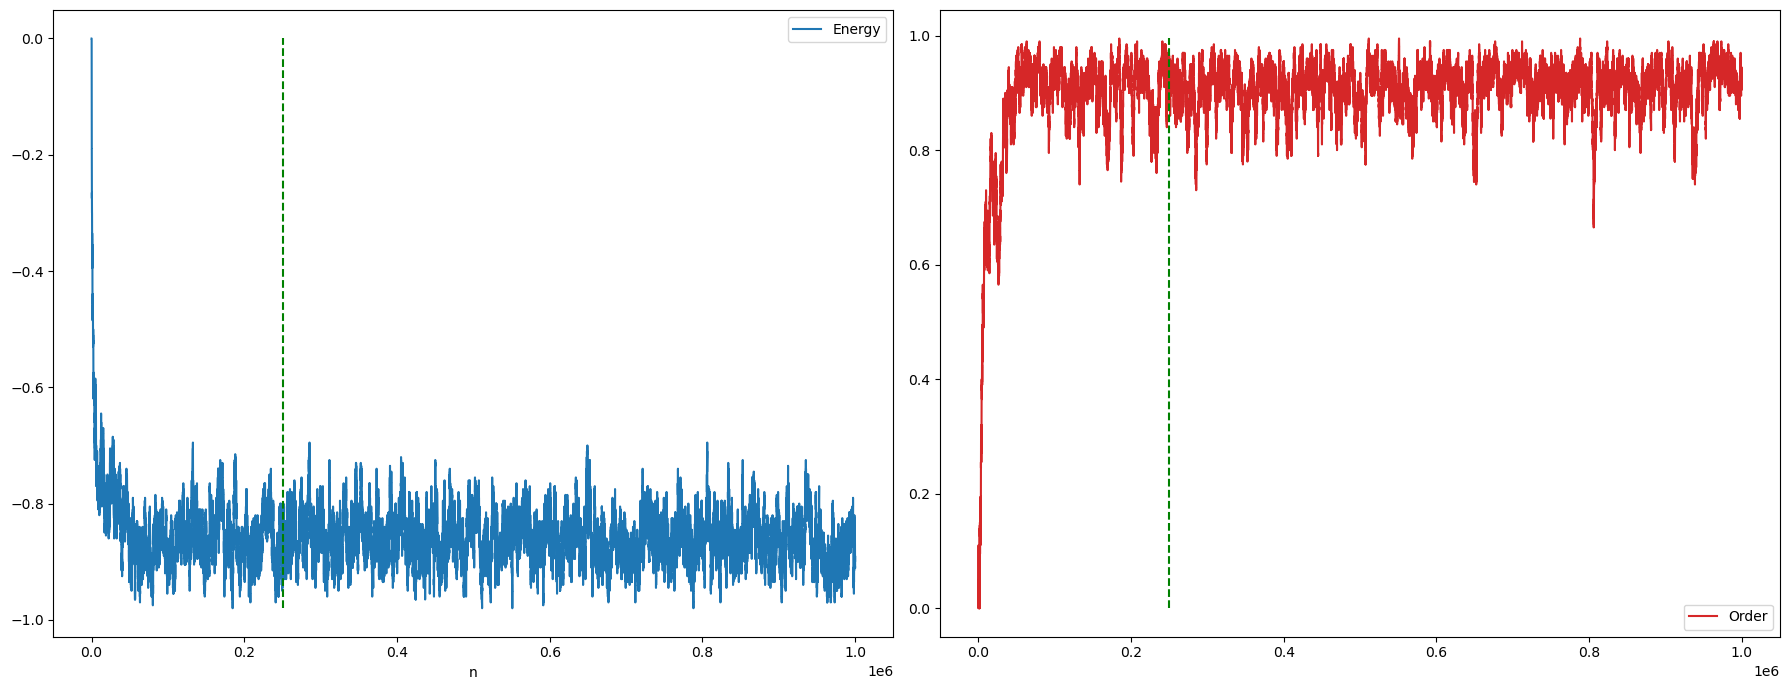

-0.8627134630487162
0.9113248715668382


In [106]:
T=1
n_max = 10**6
n_0 = int(n_max/4)
N_site=20
J=2
h=0
q=2

E,s,final_grid = one_run(N_site=N_site,T=T,J=J,n_max=n_max,h=h,q=q)
print(final_grid)
E ,s = np.array(E)/(N_site**2), np.array(s)

fig,ax = plt.subplots(1,2,figsize=(18,7))
x = np.arange(len(E))
ax[0].plot(x,E,label= "Energy")
ax[1].plot(x,s,label="Order",color="tab:red")
ax[0].set_xlabel("n")
ax[0].set_xlabel("n")
y_E = np.linspace(min(E),max(E),2)
y_s = np.linspace(min(s),max(s),2)
ax[0].plot([n_0,n_0],y_E,linestyle="dashed",color="green")
ax[1].plot([n_0,n_0],y_s,linestyle="dashed",color="green")
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()
print(np.mean(E[n_0::]))
print(abs(np.mean(s[n_0::])))

In [105]:
print(order(final_grid,q))

0.8899999999999999


In [8]:
T=1
n_max=10**3
n_0 = int(n_max/4)
N_site=10
J=1
h=0

E,s,final_grid = one_run(N_site=N_site,T=T,J=J,n_max=n_max,h=h)
E,s = np.array(E),np.array(s)/(N_site**2)

fig,ax = plt.subplots(1,2,figsize=(18,7))
x = np.arange(len(E))
ax[0].plot(x,E,label= "Energy")
ax[1].plot(x,s,label="Moment",color="tab:red")
ax[0].set_xlabel("n")
ax[0].set_xlabel("n")
y_E = np.linspace(min(E),max(E),2)
y_s = np.linspace(min(s),max(s),2)
ax[0].plot([n_0,n_0],y_E,linestyle="dashed",color="green")
ax[1].plot([n_0,n_0],y_s,linestyle="dashed",color="green")
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()
print(np.mean(E[n_0::]))
print(abs(np.mean(s[n_0::])))

[[6 8 3 6 5 1 9 9 3 9]
 [3 1 7 6 9 8 7 5 3 0]
 [6 4 5 2 8 2 4 9 1 5]
 [3 9 1 7 7 3 8 3 8 8]
 [1 5 4 5 3 1 5 0 2 9]
 [6 2 0 6 7 5 4 2 1 1]
 [3 5 5 4 0 8 0 4 6 8]
 [7 9 7 3 9 9 4 2 6 0]
 [9 6 2 5 3 1 0 9 7 8]
 [2 8 5 1 8 8 5 0 4 8]]
E_ordered= -200.0
-12.0


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
T_list = np.linspace(2,2.5,30)

E_mean = []
E_err = []
s_mean = []
s_err = []

for index, T in enumerate(T_list):
    n_max=10**6
    n_0 = int(n_max/4)
    N_site=20
    J=1

    E,s,final_grid = one_run(N_site=N_site,T=T,J=J,n_max=n_max)
    E,s = np.array(E),np.array(s)/(N_site**2)
    E_mean.append(np.mean(E))
    E_err.append(np.std(E))
    s_mean.append(abs(np.mean(s)))
    s_err.append(np.std(s))

E_mean = np.array(E_mean)
E_err = np.array(E_err)
s_mean = np.array(s_mean)
s_err = np.array(s_err)

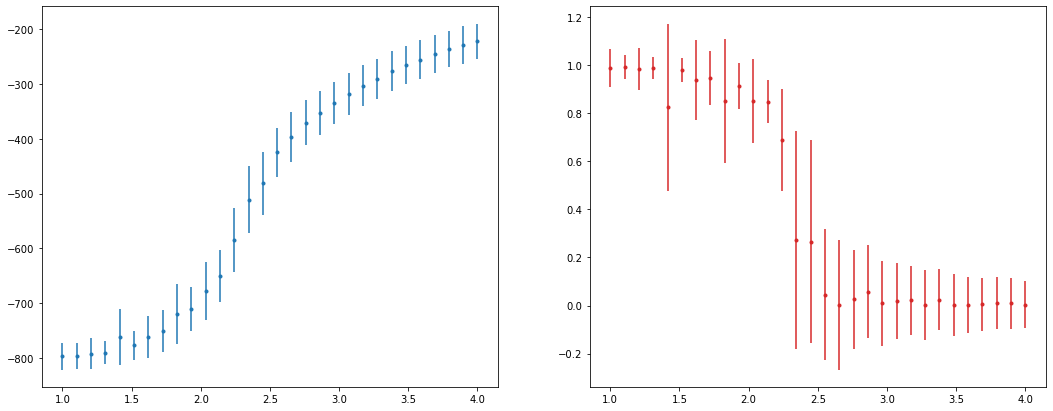

In [78]:
fig,ax = plt.subplots(1,2,figsize=(18,7))
ax[0].errorbar(T_list,E_mean,E_err,fmt='.')
ax[1].errorbar(T_list,s_mean,s_err,fmt='.',color="tab:red")
plt.show()

In [73]:
def one_run(N_site = 20, T=1,n_max=10**4,n_0=0,J=1):
    grid = random.randint(0,2,size=[N_site,N_site])
    grid = 2*grid-1
    current_energy = energy(grid,J)
    E = [current_energy]
    s = [np.sum(grid)]
    for l in range(int(n_max)):
        prev_energy = current_energy
        i,j,new_grid = spinflip(grid)
    #    delta_E = delta_site_energy(grid,i,j,J)
        delta_E = energy(new_grid,J)-energy(grid,J)
        selection = select(delta_E,T)
        if selection==1:
            grid=new_grid
            current_energy = prev_energy+delta_E
        else:
            current_energy = prev_energy
        E.append(current_energy)
        s.append(np.sum(grid))
    
    return [E,s,grid]

T=2.2
n_max=100
n_0 = int(n_max/4)
N_site=100
J=1

E,s = one_run(N_site=N_site,T=T,J=J,n_max=n_max)[:2]

In [9]:
i,j = 1,3
J=-1
test_grid = np.ones((5,5))
test_grid[i,j]=-1
test_grid[0,3]*=-1
print(energy(test_grid,J))
new_grid = np.copy(test_grid)
new_grid[i,j]*=-1
print(energy(new_grid,J))
print(test_grid,new_grid)


print(delta_site_energy(test_grid,i,j,-1))

38.0
42.0
[[ 1.  1.  1. -1.  1.]
 [ 1.  1.  1. -1.  1.]
 [ 1.  1.  1.  1.  1.]
 [ 1.  1.  1.  1.  1.]
 [ 1.  1.  1.  1.  1.]] [[ 1.  1.  1. -1.  1.]
 [ 1.  1.  1.  1.  1.]
 [ 1.  1.  1.  1.  1.]
 [ 1.  1.  1.  1.  1.]
 [ 1.  1.  1.  1.  1.]]
4.0
